# UNet сегментация

Адаптировано с: https://github.com/atsky/mkn-dl-practice/blob/main/workshops/workshop_05_cnn.ipynb

## Kaggle датасет

https://www.kaggle.com/datasets/tapakah68/segmentation-full-body-mads-dataset

In [ ]:
import os

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

import torchvision
from torchvision import transforms
from torchvision import models

from skimage import data

from PIL import Image

from tqdm import trange, tqdm

from sklearn.model_selection import train_test_split

In [ ]:
!pip install -q kaggle

In [ ]:
import os
kaggle_token = {"username":"izhanvarsky", "key":"e06d966b7ebc01cb2eaeec716e2d1cf0"}

os.environ['KAGGLE_USERNAME'] = kaggle_token['username']
os.environ['KAGGLE_KEY'] = kaggle_token['key']

In [ ]:
!kaggle datasets download -d tapakah68/segmentation-full-body-mads-dataset

 99% 470M/475M [00:06<00:00, 83.3MB/s]
100% 475M/475M [00:06<00:00, 81.0MB/s]


In [ ]:
!unzip -n -q /content/segmentation-full-body-mads-dataset.zip

In [ ]:
dataset_root = '/content/segmentation_full_body_mads_dataset_1192_img/segmentation_full_body_mads_dataset_1192_img'
images_dir = f"{dataset_root}/images"
masks_dir = f"{dataset_root}/masks"

### Проверка картинок

In [ ]:
imgs = sorted(os.listdir(images_dir))

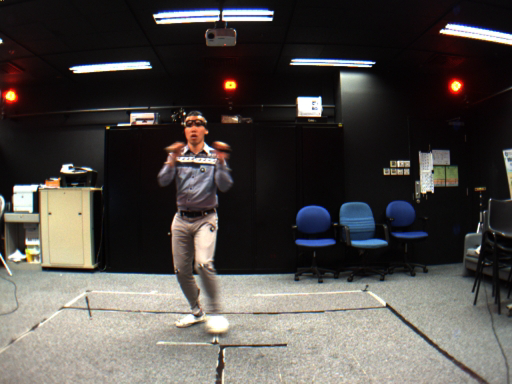

In [ ]:
img1 = Image.open(f'{images_dir}/{imgs[0]}')
img1

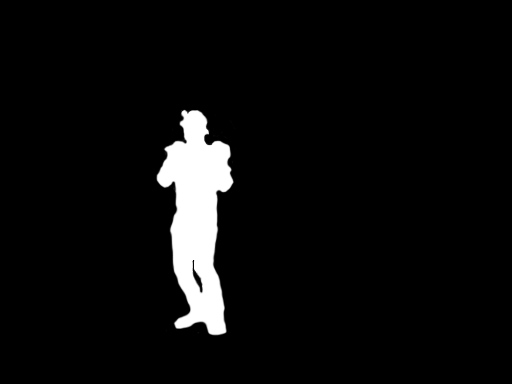

In [ ]:
Image.open(f'{masks_dir}/{imgs[0]}')

In [ ]:
img1.size

(512, 384)

In [ ]:
for img in imgs:
  cur_shape = Image.open(f'{images_dir}/{img}').size
  if cur_shape != (512, 384):
    print(f"Different size: {cur_shape}")

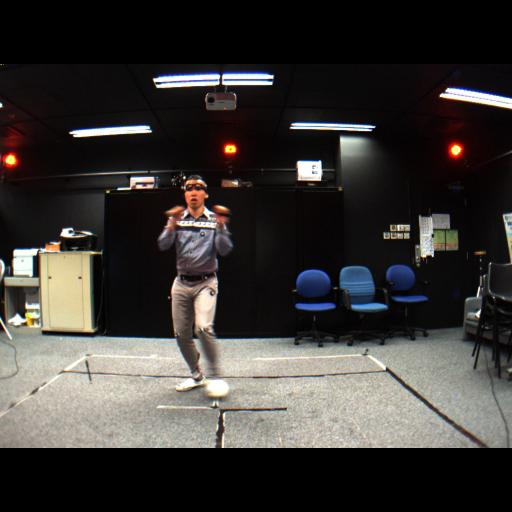

In [ ]:
# Можно было бы применить
transforms.Pad([0, (512 - 384) // 2])(img1)

## PyTorch датасет и даталоадер

In [ ]:
class SegmentationDataset(torch.utils.data.Dataset):
  def __init__(self, images_path, masks_path, imgs, transforms):
    self.images_path = images_path
    self.masks_path = masks_path
    self.imgs = imgs
    self.transforms = transforms

  def __len__(self):
    return len(self.imgs)

  def __getitem__(self, idx):
    image_path = os.path.join(self.images_path, self.imgs[idx])
    mask_path = os.path.join(self.masks_path, self.imgs[idx])

    image = Image.open(image_path)
    mask = Image.open(mask_path).convert('L')

    if self.transforms is not None:
      image = self.transforms(image)
      mask = transforms.ToTensor()(mask)

    return (image, mask)

In [ ]:
train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
batch_size = 16

trainset = SegmentationDataset(
    images_dir,
    masks_dir,
    imgs,
    train_transforms)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

In [ ]:
inputs, masks = next(iter(trainloader))
inputs.shape, masks.shape

(torch.Size([16, 3, 384, 512]), torch.Size([16, 1, 384, 512]))

## Classic U-net
U-Net: Convolutional Networks for Biomedical Image Segmentation


<img src="https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png" alt="drawing" width="800"/>


Implementation

https://pyimagesearch.com/2021/11/08/u-net-training-image-segmentation-models-in-pytorch/

In [ ]:
class Block(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.layers(x)

In [ ]:
enc_block = Block(3, 64)
x = torch.randn(1, 3, 512, 384)
enc_block(x).shape

torch.Size([1, 64, 512, 384])

In [ ]:
class Encoder(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.enc_blocks = nn.ModuleList(
            [Block(channels[i], channels[i+1]) for i in range(len(channels)-1)]
        )
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        features = []
        for block in self.enc_blocks:
            x = block(x)
            features.append(x)
            x = self.pool(x)
        return features

In [ ]:
encoder = Encoder(channels=(3, 64, 128, 256, 512, 1024))
x = torch.randn(1, 3, 512, 384)
features = encoder(x)
for ftr in features:
  print(ftr.shape)

torch.Size([1, 64, 512, 384])
torch.Size([1, 128, 256, 192])
torch.Size([1, 256, 128, 96])
torch.Size([1, 512, 64, 48])
torch.Size([1, 1024, 32, 24])


In [ ]:
class Decoder(nn.Module):
	def __init__(self, channels=(64, 32, 16)):
		super().__init__()
		self.channels = channels
		self.upconvs = nn.ModuleList(
			[nn.ConvTranspose2d(channels[i], channels[i + 1], 2, 2)
			 	for i in range(len(channels) - 1)]
    )
		self.dec_blocks = nn.ModuleList(
			[Block(channels[i], channels[i + 1]) for i in range(len(channels) - 1)]
    )

	def forward(self, x, encFeatures):
		# loop through the number of channels
		for i in range(len(self.channels) - 1):
			# pass the inputs through the upsampler blocks
			x = self.upconvs[i](x)

			x = torch.cat([x, encFeatures[i]], dim=1)
			x = self.dec_blocks[i](x)
		# return the final decoder output
		return x

In [ ]:
class UNet(nn.Module):
  def __init__(self, encChannels=(3, 16, 32, 64),
		 decChannels=(64, 32, 16),
		 nbClasses=1):
    super().__init__()
    # initialize the encoder and decoder
    self.encoder = Encoder(encChannels)
    self.decoder = Decoder(decChannels)
    # initialize the regression head and store the class variables
    self.head = nn.Conv2d(decChannels[-1], nbClasses, 1)

  def forward(self, x):
    # grab the features from the encoder
    encFeatures = self.encoder(x)
    # pass the encoder features through decoder making sure that
    # their dimensions are suited for concatenation
    decFeatures = self.decoder(encFeatures[::-1][0],
      encFeatures[::-1][1:])
    # pass the decoder features through the regression head to
    # obtain the segmentation mask
    map = self.head(decFeatures)

    return map

### Обучение

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
net = UNet()
x = torch.randn(1, 3, 384, 512)
net(x).shape

torch.Size([1, 1, 384, 512])

In [ ]:
unet = UNet().to(device)

criterion = nn.BCEWithLogitsLoss()
opt = optim.AdamW(unet.parameters(), lr=0.001)

In [ ]:
for e in range(4):
  running_loss = 0.0
  i = 0
  unet.train()

  for x, y in tqdm(trainloader):
    x = x.to(device)
    y = y.to(device)

    pred = unet(x)
    loss = criterion(pred, y)

    opt.zero_grad()
    loss.backward()
    opt.step()

    running_loss += loss.item()
    if i % 10 == 9:
        print(f"Loss: {running_loss / 10}")
        running_loss = 0
    i += 1

 13%|█▎        | 10/75 [00:13<00:42,  1.53it/s]

Loss: 0.7686388432979584


 27%|██▋       | 20/75 [00:18<00:28,  1.93it/s]

Loss: 0.37474758327007296


 40%|████      | 30/75 [00:23<00:25,  1.77it/s]

...

 80%|████████  | 60/75 [00:32<00:08,  1.80it/s]

Loss: 0.05410863794386387


 93%|█████████▎| 70/75 [00:37<00:02,  1.91it/s]

Loss: 0.053729531541466716


100%|██████████| 75/75 [00:40<00:00,  1.87it/s]


### Тестирование

In [ ]:
inputs, masks = next(iter(trainloader))

with torch.no_grad():
  pred = torch.sigmoid(unet(inputs.to(device)))

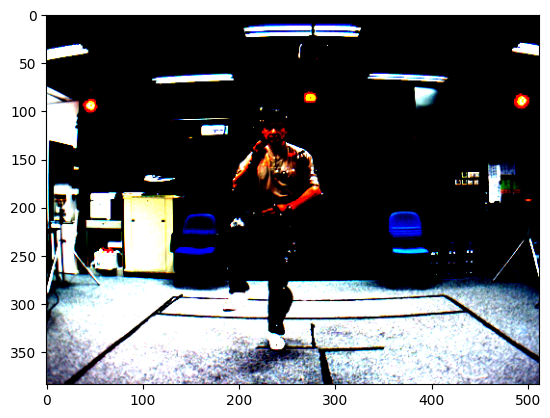

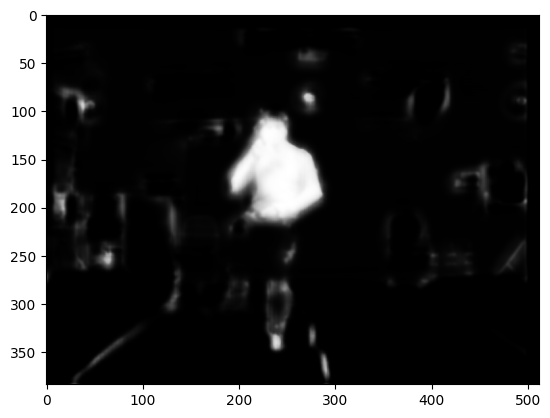

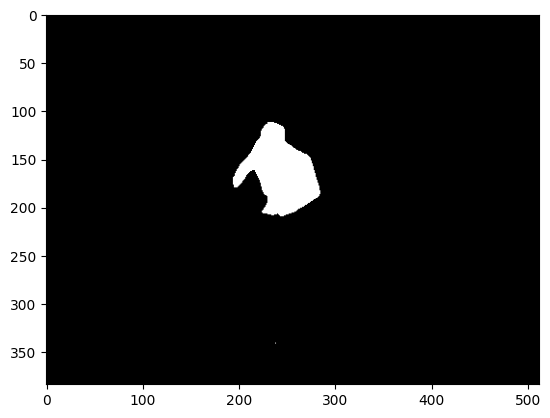

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

npimg = inputs[0].detach().cpu().numpy()
plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.show()

npimg = pred[0, 0].detach().cpu().numpy()
plt.imshow(npimg, cmap='gray')
plt.show()

clipped_img = np.where(npimg < 0.85, 0, 1)
plt.imshow(clipped_img, cmap='gray')
plt.show()

# YOLO-seg

In [ ]:
url = "https://webnews.bg/uploads/images/74/8974/218974/768x432.jpg?_=1455016484"

<Response [200]>


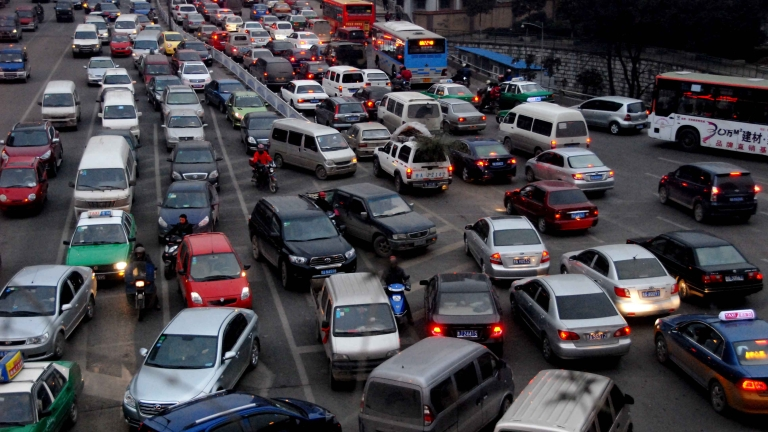

In [ ]:
from PIL import Image
import requests
from io import BytesIO

response = requests.get(url)
print(response)
img = Image.open(BytesIO(response.content))
img

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n-seg.pt').to(device)

In [ ]:
res = model.predict(img, classes=[2, 5, 7], conf=0.5)[0]


0: 384x640 29 cars, 1 bus, 8.9ms
Speed: 3.1ms preprocess, 8.9ms inference, 3.2ms postprocess per image at shape (1, 3, 384, 640)


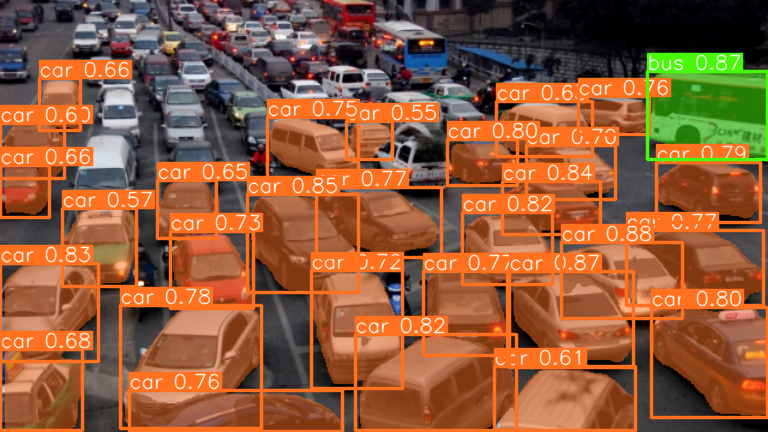

In [ ]:
im_array = res.plot()  # plot a BGR numpy array of predictions
im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
im

**Выдать задание:**

Разобраться и рассказать, как работает instance segmentation в yolo. Показать в исходном коде что и где написано. Объяснить, за счет чего предсказываются маски, как обработка и создание датасета происходит, какие функции потери и т.п. Нужно довольно подробно, буду задавать вопросы

# Segment Anything (SAM) and pytorch for segmentation

См. отдельные ноутбуки

# Object Tracking

[MOT Challenge](https://motchallenge.net/)

[Boxmot](https://github.com/mikel-brostrom/boxmot) - модуль с реализациями различных трекеров

In [ ]:
!pip install boxmot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.6/755.6 MB 992.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.3/915.3 kB 24.0 MB/s eta 0:00:00


In [ ]:
import cv2
import torch
from boxmot import OcSort
from ultralytics import YOLO
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

model = YOLO("yolo11n.pt").to(device)

def process_video(video_path, output_path):
    cap = cv2.VideoCapture(video_path)
    tracker = OcSort(
        det_thresh=0.2,
        max_age=10,
        min_hits=3,
        asso_threshold=0.15,
        delta_t=1,
        asso_func="diou",
        inertia=0.2,
    )

    if not cap.isOpened():
        print("Ошибка открытия видео файла")
        return

    # Получение параметров видео
    frame_width = int(cap.get(3))
    frame_height = int(cap.get(4))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    # Создание видеозаписи
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Получение детекций
        results = model(
            frame,
            conf=0.3,
            classes=[0],
            imgsz=1280,
        )
        detections = []

        for result in results:
            for box in result.boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                conf = box.conf[0].item()
                cls = int(box.cls[0].item())

                detections.append([x1, y1, x2, y2, conf, cls])

        detections = torch.tensor(detections)
        tracks = tracker.update(detections.cpu().numpy(), np.empty((0,0)))

        # Отображаем треки
        for track in tracks:
            x1, y1, x2, y2, track_id = map(int, track[:5])
            conf = track[5]
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, f"{track_id} {conf:.2f}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        out.write(frame)

    cap.release()
    out.release()
    # cv2.destroyAllWindows()

process_video("video.mp4", "output.mp4")


0: 736x1280 27 persons, 16.1ms
Speed: 6.4ms preprocess, 16.1ms inference, 1.5ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 29 persons, 14.2ms
Speed: 5.5ms preprocess, 14.2ms inference, 1.4ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 29 persons, 17.1ms
Speed: 8.7ms preprocess, 17.1ms inference, 1.8ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 30 persons, 14.3ms
Speed: 12.2ms preprocess, 14.3ms inference, 1.7ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 29 persons, 14.3ms
Speed: 8.7ms preprocess, 14.3ms inference, 2.0ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 29 persons, 14.3ms
Speed: 8.7ms preprocess, 14.3ms inference, 1.7ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 29 persons, 14.2ms
Speed: 8.7ms preprocess, 14.2ms inference, 1.7ms postprocess per image at shape (1, 3, 736, 1280)

0: 736x1280 29 persons, 14.3ms
Speed: 9.6ms preprocess, 14.3ms inference, 1.7ms postproc

**Выдать задание**

В boxmot лежат методы на основе математики (фильтр Калмана и т.п.), однако можно целую нейросеть обучить для задачи трекинга. Найдите такие методы и библиотеки, запустите их на тестовых видео и покажите результаты. Доп.баллы если разбересь с форматом датасета, обучите свой трекер и покажете хорошее качество.